In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import modules.loaddata
import modules.loadroot
import importlib

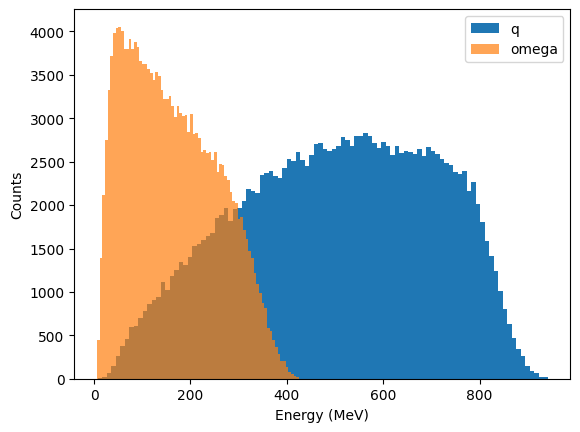

In [2]:
importlib.reload(modules.loadroot)
importlib.reload(modules.loaddata)
mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
plt.hist(q_vals, bins=100, label="q")
plt.hist(omega_vals, bins=100, alpha=0.7, label="omega")
plt.legend()
plt.xlabel("Energy (MeV)")
plt.ylabel("Counts")
None

Text(0.5, 0, 'q')

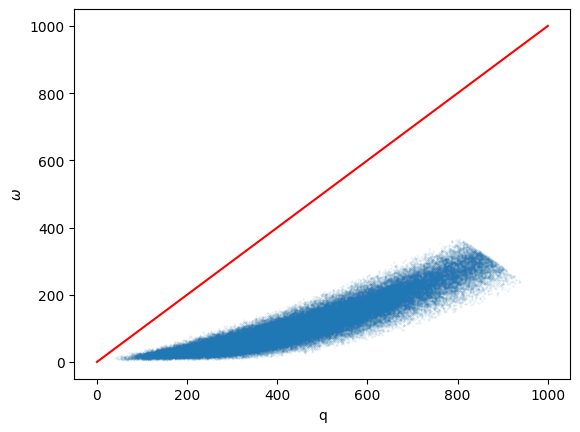

In [3]:
plt.scatter(q_vals, omega_vals, s=0.1, alpha=0.1)
plt.plot([0, 1000], [0,1000], color="red")
plt.ylabel("$\\omega$")
plt.xlabel("q")

In [23]:
mom_outs

array([[ 787.19347258,  416.39622144,  298.63154172,  588.16948184],
       [ 844.70746203,  268.23507478, -192.65163924,  770.2612375 ],
       [ 796.99039271,  527.3483635 ,   62.55875739,  584.82491269],
       ...,
       [ 646.22878826,  409.40549965, -219.51965544,  436.63061225],
       [ 758.03735046, -281.10217901, -397.43509087,  571.38771883],
       [ 879.71061474, -207.25627878,  322.38276689,  784.75559204]],
      shape=(174488, 4))

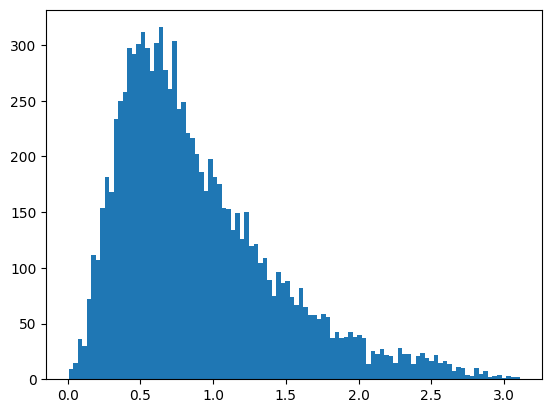

In [24]:
# plt.scatter(mom_outs[:,3], sideways_out, s=1)
plt.hist(angle_out, bins=100)
pass

In [25]:
sideways_out = np.sqrt(mom_outs[:,1]**2 + mom_outs[:,2]**2)
angle_out = np.arctan2(sideways_out, mom_outs[:,3])
ang2_out = np.arccos((k**2 + k_prim**2 - q_vals**2) / (2 * k * k_prim))

plt.hist(angle_out, bins=100,label="Vector angle out")
plt.hist(ang2_out, bins=100, label="momentum angle out", alpha=0.7)
plt.legend()
# They agree :)
None

ValueError: operands could not be broadcast together with shapes (51,) (174488,) 

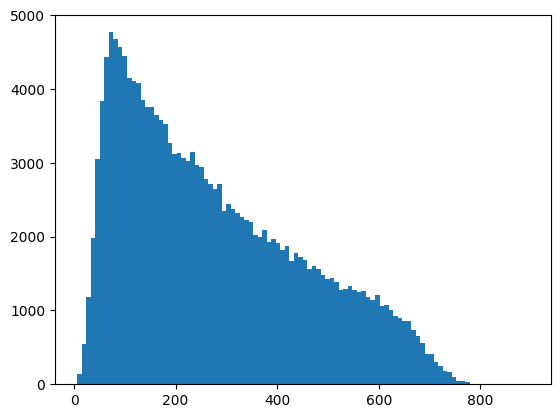

In [26]:
plt.hist(omega_vals, bins=100)
pass

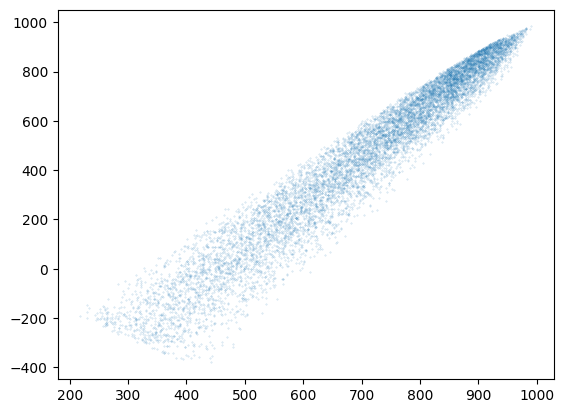

In [5]:
plt.scatter(mom_outs[:,0], mom_outs[:,3], alpha = 0.3, s=0.1)

In [4]:
lfg_q, lfg_data = modules.loaddata.load_response_functions("../week4/results/", "responses_C12_CC_LFG")
t2k_bins, t2k_vals = modules.loaddata.load_t2k("data/t2k/t2kflux_2020_plus250kA_nominal_nd280.txt")


In [139]:
eps = mom_ins[:, 0]
eps_prim = mom_outs[:, 0]

k = np.sqrt(np.sum(mom_ins[:, 1:]** 2, axis=1))
k_prim = np.sqrt(np.sum(mom_outs[:, 1:] ** 2, axis=1))

m_l = 0.511 # MeV

Q_sq = q_vals**2 - omega_vals**2

v00 = 2 * eps * eps_prim * ( 1 - k_prim/eps_prim * np.cos(angle_out) )
vzz = omega_vals**2 / q_vals**2 * (m_l ** 2 + v00) + m_l**2 / q_vals**2 * (m_l**2 + 2 * omega_vals * (eps + eps_prim) + q_vals**2)
v0z = omega_vals / q_vals * (m_l**2 + v00) + m_l**2 / q_vals * (eps + eps_prim)
vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * q_vals**2) - m_l**2 / q_vals**2 * (m_l**2 / 2 + omega_vals * (eps + eps_prim))
vxy = Q_sq * (eps + eps_prim) / q_vals - m_l**2 * omega_vals / q_vals

coeffs = np.array([v00, vzz, v0z, vxx, vxy]).T

/tmp/ipykernel_884863/2279570475.py:17: RuntimeWarning: invalid value encountered in arccos
  costheta = np.arccos(temp)


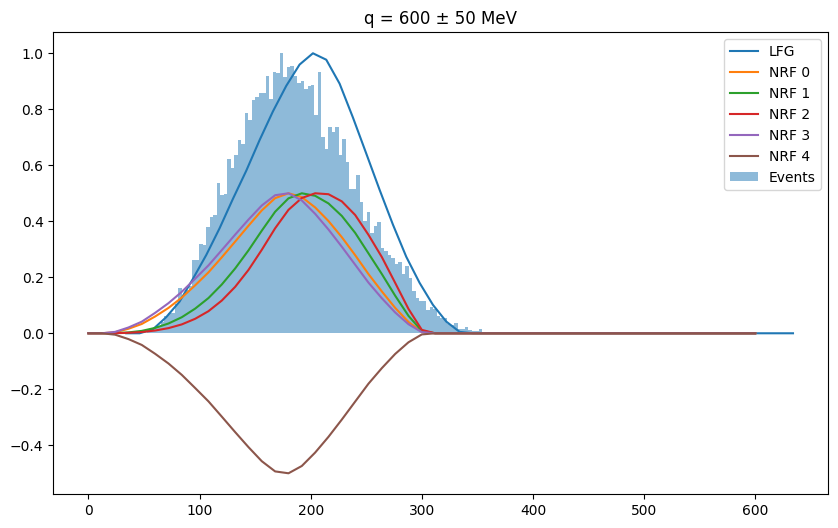

In [13]:
target_q = 600
q_delta = 50

eps = 1000
#muon mass
m_l = 105.66

lfg_idx = np.argmin(np.abs(lfg_q - target_q))
omega = lfg_data[lfg_idx,0,0]
eps_prim = eps - omega
k = eps
k_prim = np.sqrt(eps_prim**2 - m_l**2)

Q_sq = target_q**2 - omega**2

temp = (k**2 + k_prim**2 - target_q**2) / (2 * k * k_prim)
costheta = np.arccos(temp)
costheta = np.nan_to_num(costheta)


v00 = 2 * eps * eps_prim * ( 1 + k_prim/eps_prim * costheta )
vzz = omega**2 / target_q**2 * (m_l ** 2 + v00) + m_l**2 / target_q**2 * (m_l**2 + 2 * omega * (eps + eps_prim) + target_q**2)
v0z = omega / target_q * (m_l**2 + v00) + m_l**2 / target_q * (eps + eps_prim)
vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * target_q**2) - m_l**2 / target_q**2 * (m_l**2 / 2 + omega * (eps + eps_prim))
vxy = Q_sq * (eps + eps_prim) / target_q - m_l**2 * omega / target_q
# r00 r0z rzz rxx rxy
coeffs = np.array([v00, -v0z, vzz, vxx, -vxy])



mask = np.abs(q_vals - target_q) < q_delta

counts, bins = np.histogram(omega_vals[mask], bins=100)
normcounts = counts / np.max(counts)

cross_section = k_prim / eps * np.sum(lfg_data[lfg_idx, :, 1] * coeffs, axis=0)

plt.figure(figsize=(10,6))



plt.plot(lfg_data[lfg_idx, 0, 0] + 34, cross_section / np.max(cross_section), label="LFG")
for cidx in range(5):
    plt.plot(lfg_data[lfg_idx, cidx, 0], lfg_data[lfg_idx, cidx, 1] / np.max(np.abs(lfg_data[lfg_idx, cidx, 1])) * 0.5, label=f"NRF {cidx}")
plt.bar(bins[:-1], normcounts, width=np.diff(bins), alpha=0.5, label="Events")
plt.title(f"q = {target_q} ± {q_delta} MeV")
plt.legend()

In [68]:
coeffs[:,30]

array([ 2064520.35806812, -1313139.11884087,   841069.43749828,
         680489.49588492,  -342741.57864   ])

[  10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.   10.
   10.   10.   10.   10.   10.   10.   10.   10.   20.   20.   20.   20.
   20.   50.   50.   50.   50.   50.   50.  100.  100.  100.  100.  100.
  100.  100.  100.  100.  100.  100.  100.  200.  200.  200.  200.  200.
  200.  200.  200.  500.  500. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000.]


Text(0.5, 1.0, 'T2K Flux')

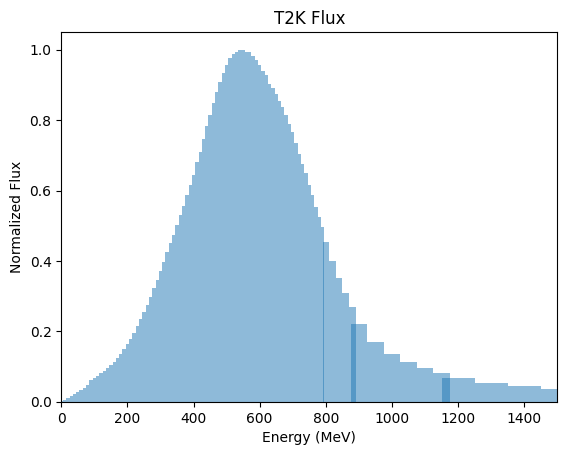

In [9]:
plt.bar(t2k_bins[:,0], t2k_vals / np.max(t2k_vals), width=t2k_bins[:,1]-t2k_bins[:,0], alpha=0.5, label="T2K Flux")
plt.xlim(0, 1500)
print(t2k_bins[:,1] - t2k_bins[:,0])
plt.xlabel("Energy (MeV)")
plt.ylabel("Normalized Flux")
plt.title("T2K Flux")

# NuWro T2K Beam profile

15.0 1985.0 0.004385542168674698 0.009397590361445784 0.015481927710843373 0.021445783132530122 0.027349397590361445 0.033012048192771086 0.03921686746987952 0.04891566265060241 0.06204819277108434 0.06807228915662651 0.07349397590361446 0.08072289156626505 0.08795180722891566 0.09578313253012048 0.10421686746987951 0.11385542168674699 0.1246987951807229 0.13614457831325302 0.1493975903614458 0.163855421686747 0.17951807228915662 0.19578313253012047 0.21445783132530122 0.23373493975903614 0.2536144578313253 0.2753012048192771 0.2987951807228916 0.3228915662650602 0.3463855421686747 0.372289156626506 0.39759036144578314 0.42650602409638555 0.4506024096385542 0.4746987951807229 0.5018072289156627 0.5295180722891566 0.5548192771084337 0.5861445783132531 0.6144578313253012 0.6445783132530121 0.6807228915662651 0.7108433734939759 0.7469879518072289 0.7831325301204819 0.8132530120481928 0.8493975903614458 0.8795180722891566 0.9096385542168675 0.9337349397590361 0.9578313253012049 0.975903614

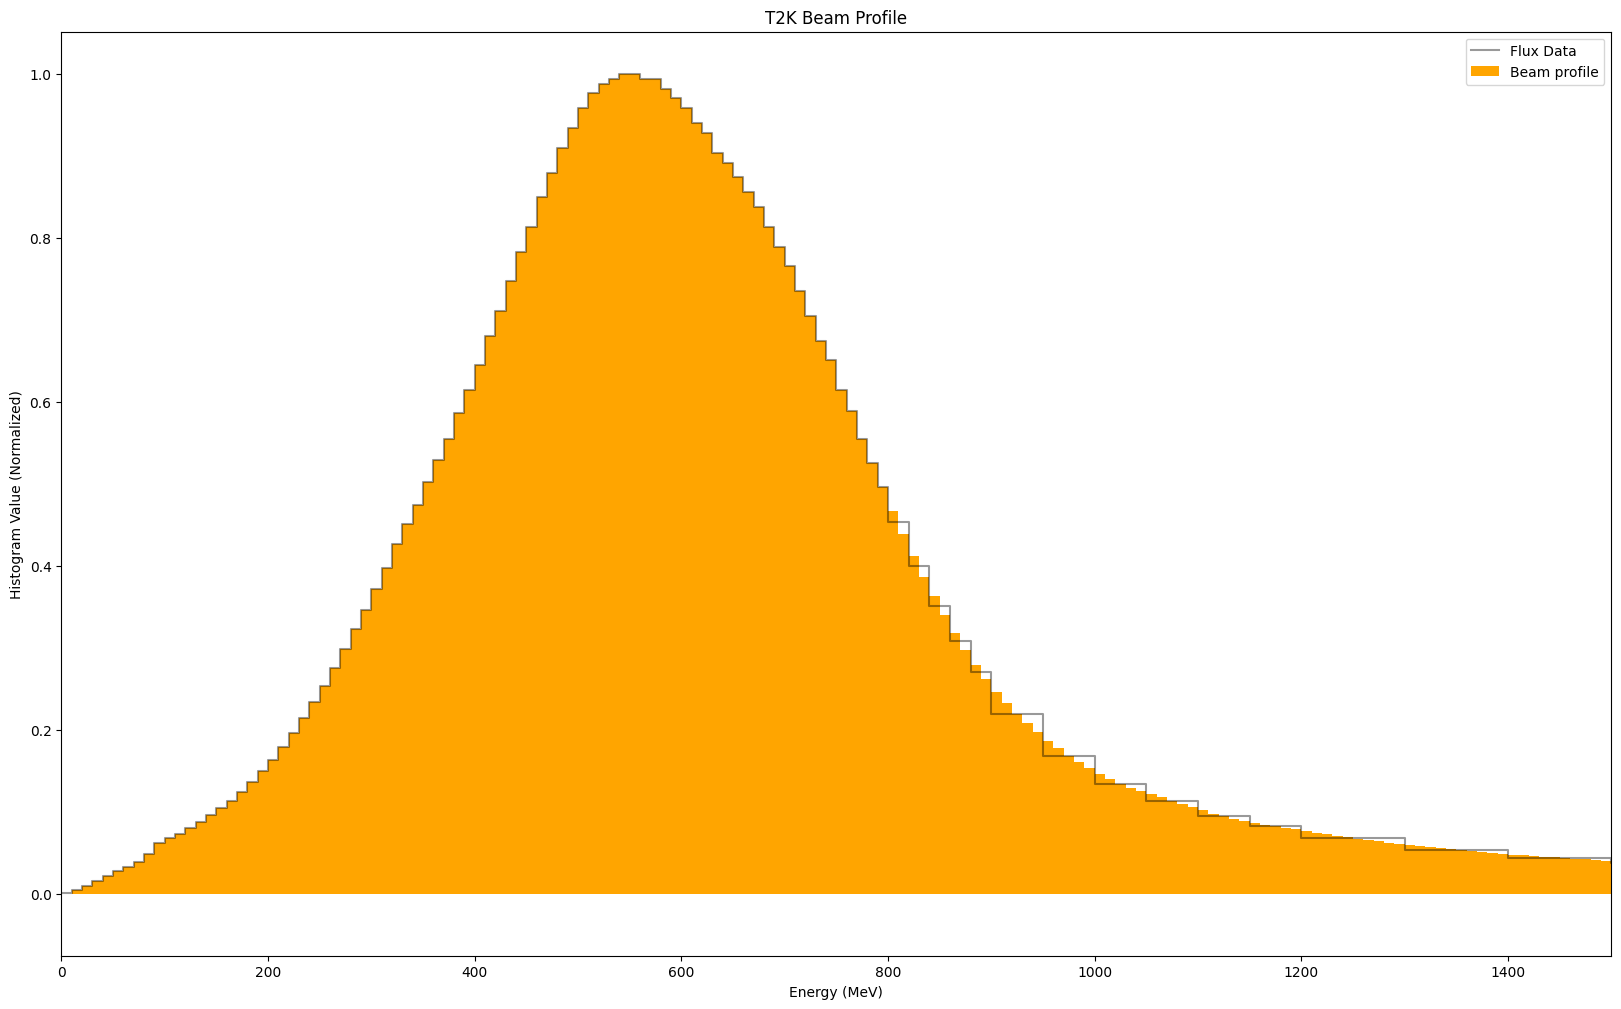

In [89]:
import scipy.interpolate
stepsize = 10
coordx = []
coordy = []
for i in range(len(t2k_bins)):
    xcoord = (t2k_bins[i][0] + t2k_bins[i][1]) / 2
    if xcoord > 1500:
        break
    coordx.append(xcoord)
    coordy.append(t2k_vals[i])

xpoints = np.arange(final_min, final_max, stepsize)

ypoints = scipy.interpolate.CubicSpline(coordx, coordy)(xpoints)


datax = []
datay = []
for x, y in zip(t2k_bins, t2k_vals):
    if x[0] > 1500:
        break
    datax.append((x[0]))
    datax.append((x[1]))
    datay.append(y)
    datay.append(y)

plt.figure(figsize=(20,12))
plt.plot(datax, datay / np.max(datay), label="Flux Data", color="black", drawstyle="steps-post", alpha=0.4)
plt.bar(xpoints, ypoints / np.max(ypoints), width=stepsize, label="Beam profile", color="orange")
plt.xlim(0, 1500)
plt.xlabel("Energy (MeV)")
plt.ylabel("Histogram Value (Normalized)")
plt.title("T2K Beam Profile")
plt.legend()

bins = ""
for y in ypoints:
    bins += f"{y/np.max(ypoints)} "

print(f"{np.min(xpoints)} {np.max(xpoints)} {bins}")

In [11]:
import numpy as np

def amp3(s, t, m, M, Mp, Mn, F1, F2, FP, FA):
    """
    Calculates the amp3 amplitude.
    Fully vectorized: inputs can be scalars or NumPy arrays.
    """
    # KG has different convention for Fp
    FP = FP * 2.0
    
    AMP = (2.0 * (
        -3.0 * (F2**2) * (m**4) * (Mn**2) 
        + (FP**2) * (m**4) * (Mn**2) 
        - 2.0 * (F2**2) * (m**2) * (Mn**4) 
        - 2.0 * (F2**2) * (m**4) * Mn * Mp 
        - 2.0 * (FP**2) * (m**4) * Mn * Mp 
        + (F2**2) * (m**4) * (Mp**2) 
        + (FP**2) * (m**4) * (Mp**2) 
        + 2.0 * (F2**2) * (m**2) * (Mp**4) 
        + 4.0 * (F2**2) * (m**2) * (Mn**2) * s 
        - 4.0 * (F2**2) * (m**2) * (Mp**2) * s 
        - (F2**2) * (m**4) * t 
        - (FP**2) * (m**4) * t 
        + (F2**2) * (m**2) * (Mn**2) * t 
        - (FP**2) * (m**2) * (Mn**2) * t 
        - 2.0 * (F2**2) * (Mn**4) * t 
        - 2.0 * (F2**2) * (m**2) * Mn * Mp * t 
        + 2.0 * (FP**2) * (m**2) * Mn * Mp * t 
        - 3.0 * (F2**2) * (m**2) * (Mp**2) * t 
        - (FP**2) * (m**2) * (Mp**2) * t 
        - 2.0 * (F2**2) * (Mp**4) * t 
        + 4.0 * (F2**2) * (m**2) * s * t 
        + 4.0 * (F2**2) * (Mn**2) * s * t 
        + 4.0 * (F2**2) * (Mp**2) * s * t 
        - 4.0 * (F2**2) * (s**2) * t 
        + (F2**2) * (m**2) * (t**2) 
        + (FP**2) * (m**2) * (t**2) 
        + 2.0 * (F2**2) * (Mn**2) * (t**2) 
        + 4.0 * (F2**2) * Mn * Mp * (t**2) 
        + 2.0 * (F2**2) * (Mp**2) * (t**2) 
        - 4.0 * (F2**2) * s * (t**2) 
        + 8.0 * (FA**2) * (M**2) * (
            -2.0 * (Mp**2) * s 
            + 2.0 * (s**2) 
            + (m**2) * ((Mn**2) + 2.0 * Mn * Mp + (Mp**2) - 2.0 * s - t) 
            + (Mn**2) * (2.0 * (Mp**2) - 2.0 * s - t) 
            - 2.0 * Mn * Mp * t 
            - (Mp**2) * t 
            + 2.0 * s * t 
            + (t**2)
        ) 
        + 8.0 * (F1**2) * (M**2) * (
            -2.0 * (Mp**2) * s 
            + 2.0 * (s**2) 
            + (m**2) * ((Mn**2) - 2.0 * Mn * Mp + (Mp**2) - 2.0 * s - t) 
            + (Mn**2) * (2.0 * (Mp**2) - 2.0 * s - t) 
            + 2.0 * Mn * Mp * t 
            - (Mp**2) * t 
            + 2.0 * s * t 
            + (t**2)
        ) 
        - 8.0 * FA * M * (
            -(F2 * (Mn + Mp) * (
                ((Mn**2) + (Mp**2) - 2.0 * s - t) * t 
                + (m**2) * ((Mn**2) - (Mp**2) + t)
            )) 
            + FP * (m**2) * (
                (m**2) * Mn 
                + (Mn**3) 
                - (Mn**2) * Mp 
                + Mp * s 
                - Mn * (s + t)
            )
        ) 
        - 8.0 * F1 * M * (
            -2.0 * FA * M * (
                ((Mn**2) + (Mp**2) - 2.0 * s - t) * t 
                + (m**2) * ((Mn**2) - (Mp**2) + t)
            ) 
            + F2 * (
                (m**4) * Mn 
                + (Mn + Mp) * ((Mn**2) - 2.0 * Mn * Mp + (Mp**2) - t) * t 
                + (m**2) * (Mn * ((Mp**2) - s) + Mp * (-(Mp**2) + s + t))
            )
        )
    )) / (M**2)

    return AMP



In [79]:
# CONSTANTS
Mp = 938.27 # MeV
Mn = 939.57 # MeV
M = (Mp + Mn) / 2.0
Mass2 = M**2

In [ ]:
def amp2(s, t, m, M, Mp, Mn, F1, F2, FP, FA):
    FP*=2; # KG has different convention for Fp    

    F1F1=F1*F1
    F2F2=F2*F2
    FPFP=FP*FP
    FAFA=FA*FA
    mm=m*m
    MM=M*M
    MnMn=Mn*Mn
    MpMp=Mp*Mp
    ss=s*s
    tt=t*t

    AMP = (2*(-3*F2F2*mm*mm*MnMn + FPFP*mm*mm*MnMn -
           2*F2F2*mm*MnMn*MnMn - 2*F2F2*mm*mm*Mn*Mp -
           2*FPFP*mm*mm*Mn*Mp + F2F2*mm*mm*MpMp +
           FPFP*mm*mm*MpMp + 2*F2F2*mm*MpMp*MpMp +
           4*F2F2*mm*MnMn*s -
           4*F2F2*mm*MpMp*s - F2F2*mm*mm*t -
           FPFP*mm*mm*t + F2F2*mm*MnMn*t -
           FPFP*mm*MnMn*t - 2*F2F2*MnMn*MnMn*t -
           2*F2F2*mm*Mn*Mp*t + 2*FPFP*mm*Mn*Mp*t -
           3*F2F2*mm*MpMp*t -
           FPFP*mm*MpMp*t - 2*F2F2*MpMp*MpMp*t +
           4*F2F2*mm*s*t + 4*F2F2*MnMn*s*t +
           4*F2F2*MpMp*s*t - 4*F2F2*ss*t +
           F2F2*mm*tt + FPFP*mm*tt +
           2*F2F2*MnMn*tt + 4*F2F2*Mn*Mp*tt +
           2*F2F2*MpMp*tt - 4*F2F2*s*tt +
           8*FAFA*MM*
                (-2*MpMp*s + 2*ss +
                  mm*(MnMn + 2*Mn*Mp + MpMp - 2*s - t) +
                  MnMn*(2*MpMp - 2*s - t) 
                  - 2*Mn*Mp*t - MpMp*t +
                  2*s*t + tt
                  ) 
              + 8*F1F1*MM*
                        (-2*MpMp*s + 2*ss +
                          mm*(MnMn - 2*Mn*Mp + MpMp - 2*s - t) +
                          MnMn*(2*MpMp - 2*s - t) + 2*Mn*Mp*t - MpMp*t +
                          2*s*t + tt
                         ) 
          - 8*FA*M*
            (-(F2*(Mn + Mp)*((MnMn + MpMp - 2*s - t)*t +
                   mm*(MnMn - MpMp + t))) +
              FP*mm*(mm*Mn + Mn*MnMn - MnMn*Mp + Mp*s - Mn*(s + t))
             ) 
         - 8*F1*M*
            (-2*FA*M*((MnMn + MpMp - 2*s - t)*t +
                 mm*(MnMn - MpMp + t)) +
              F2*(mm*mm*Mn + (Mn + Mp)*(MnMn - 2*Mn*Mp +
                    MpMp - t)*t 
                    + mm*(Mn*(MpMp - s) + Mp*(-MpMp + s+ t))
                  )
             )
      )
    )/MM

    return AMP

def ff(Q2):
  Ge = 0
  Gm = 0
  f1 = 0
  f2 = 0
  F1s = 0
  F2s = 0

  tau = Q2 / (4 * Mass2);
  f1p=0
  f1n=0
  f2p=0
  f2n=0;
  
  


  Ge = GEp - GEn;
  Gm = GMp - GMn;
  
  f1 = (Ge + tau * Gm) / (1 + tau);
  f2 = (Gm - Ge) / (1 + tau);
  
  return f1, f2

In [80]:

ff(100)

NameError: name 'GEp' is not defined

In [62]:
def qel_amp(Enu,q2,m,M,F1,F2,Fp,Fa):
    MM=M*M
    mm=m*m
    x = q2 / MM
    faa=Fa*Fa
    fpp=Fp*Fp
    f11=F1*F1
    f22=F2*F2
    
    A =  (+ (4 - x) * faa
             - (4 + x) * f11
             - x * f22 * (1 + x / 4)
             - 4 * x * F1 * F2
             - mm / MM * ( (F1+F2)**2 + (Fa + 2*Fp)**2 + (x-4)*fpp )
            )* (mm - q2)/(4 * MM) 

    B = -x * Fa * (F1 + F2);

    C = (faa + f11  - x/4 * f22) / 4;

    #  s - u
    su = 4 * M * Enu + q2 - mm;
    suM2 = su / MM;
    ABC = A + suM2*(B  + suM2*C) ;
    return ABC;

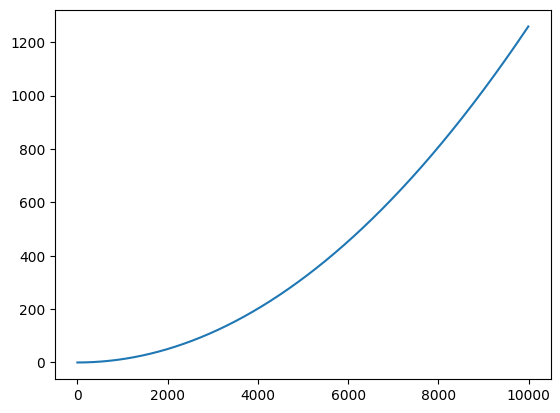

In [76]:
# MeV = 10**6
Mn = 939.565 # MeV
F1 = F2 = FP = FA = 1.0
F1 = 20
span = 10**4
wcoord = np.arange(0, span, span/1000)
s = (wcoord + m_l)**2 - wcoord**2 # Invariant mass squared
res = amp2(wcoord, target_q, m_l, 12*Mn, Mn, Mn, F1, F2, FP, FA)
res = qel_amp(wcoord, target_q, m_l, 12*Mn, F1, F2, FP, FA)
plt.plot(wcoord, res)


Text(0, 0.5, 'xsec')

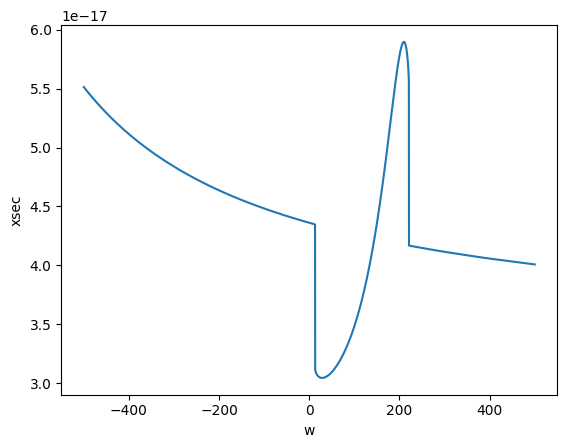

In [140]:
for i in range(1):
    q = []
    c = []
    with open(f"output.txt", "r") as f:
        data = f.read()
        for line in data.splitlines():
            split = line.split()
            q.append(float(split[0]))
            c.append(float(split[1]))
    # plt.xlim(110, 170)
    # plt.yscale("log")
    plt.plot(q, c)
plt.xlabel("w")
plt.ylabel("xsec")